In [1]:
#insurance csv 
import pandas as pd
import seaborn as sns
# load the dataset
insurance = pd.read_csv("insurance.csv")



In [2]:
#check for null values
insurance.isnull().sum()


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [3]:
#mean median mode
insurance.mean(numeric_only=True)
insurance.median(numeric_only=True)
insurance.mode(numeric_only=True)
# avg charges by smoker status
insurance.groupby("smoker")["charges"].mean()




smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64

In [4]:
insurance



,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [5]:
#avg bmi by sex
insurance.groupby("sex")["bmi"].mean()


sex
female    30.377749
male      30.943129
Name: bmi, dtype: float64

In [6]:
insurance["age"].describe()

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

In [7]:
#iqr for age
Q1 = insurance["age"].quantile(0.25)
Q3 = insurance["age"].quantile(0.75)
IQR = Q3 - Q1
print(Q1 )
print(Q3)
print(IQR)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(upper_bound)
print(lower_bound)


27.0
51.0
24.0
87.0
-9.0


In [8]:
#map sex to numeric
insurance["sex"] = insurance["sex"].map({"male": 0, "female": 1})
insurance


,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,no,northwest,10600.54830
1334,18,1,31.920,0,no,northeast,2205.98080
1335,18,1,36.850,0,no,southeast,1629.83350
1336,21,1,25.800,0,no,southwest,2007.94500


<Axes: xlabel='charges', ylabel='Count'>

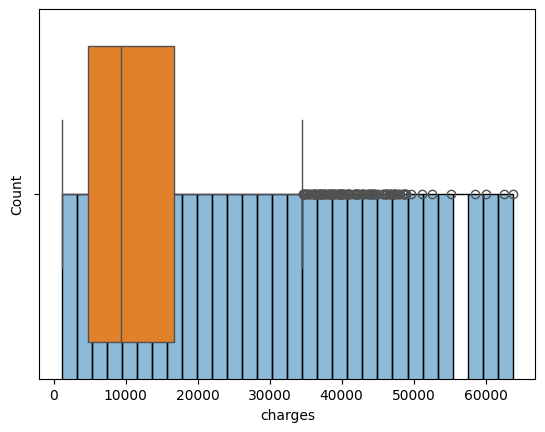

In [9]:
#plotting
sns.histplot(insurance["charges"], kde=True)    
sns.boxplot(x=insurance["charges"])
# sns.scatterplot(x=insurance["age"], y=insurance["charges"])
# sns.barplot(x=insurance["smoker"], y=insurance["charges"])

<Axes: xlabel='age', ylabel='charges'>

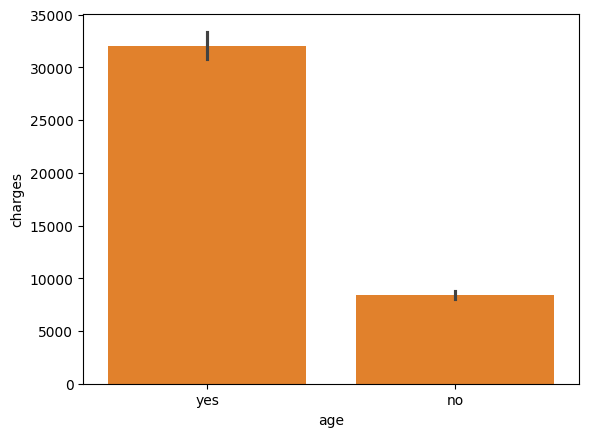

In [10]:
sns.scatterplot(x=insurance["age"], y=insurance["charges"])
sns.barplot(x=insurance["smoker"], y=insurance["charges"])

<Axes: xlabel='age_group', ylabel='charges'>

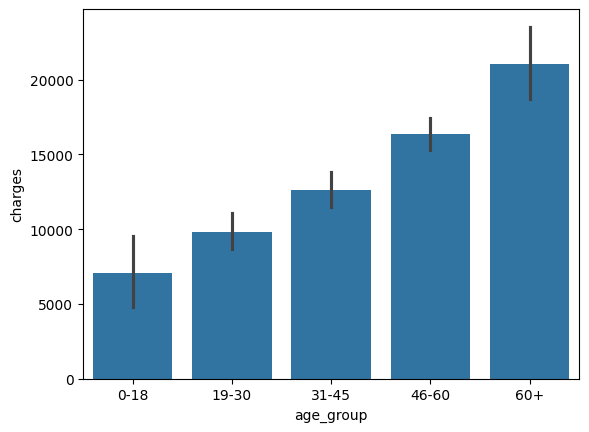

In [11]:
#differente age groups barplot
insurance["age_group"] = pd.cut(insurance["age"], bins=[0, 18, 30, 45, 60, 100], labels=["0-18", "19-30", "31-45", "46-60", "60+"])
sns.barplot(x=insurance["age_group"], y=insurance["charges"])   


<Axes: xlabel='region', ylabel='Count'>

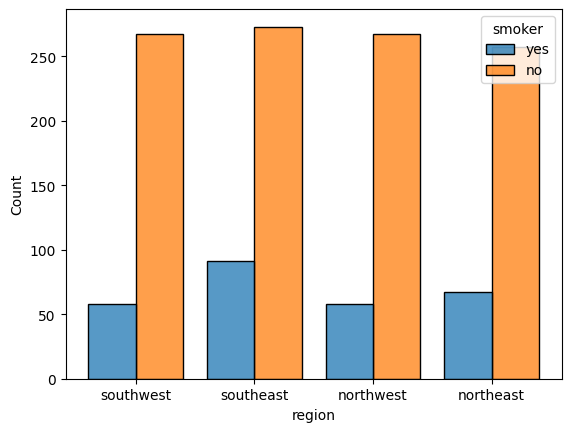

In [12]:
#histogram of region and smoker status
sns.histplot(data=insurance, x="region", hue="smoker", multiple="dodge", shrink=0.8)


<Axes: xlabel='region', ylabel='count'>

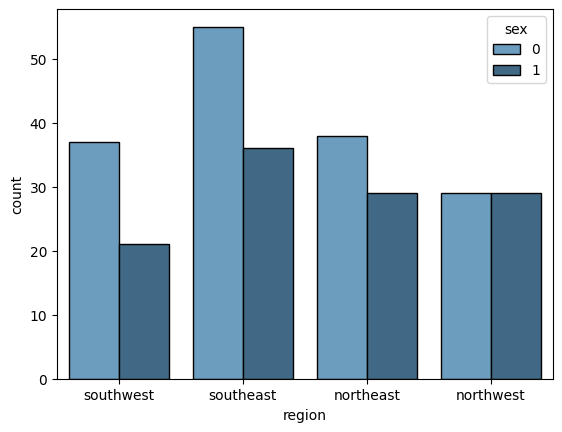

In [20]:
sns.countplot(data= insurance[insurance["smoker"] == "yes"], x="region", hue="sex", palette="Blues_d",edgecolor="black")


<Axes: xlabel='age', ylabel='Count'>

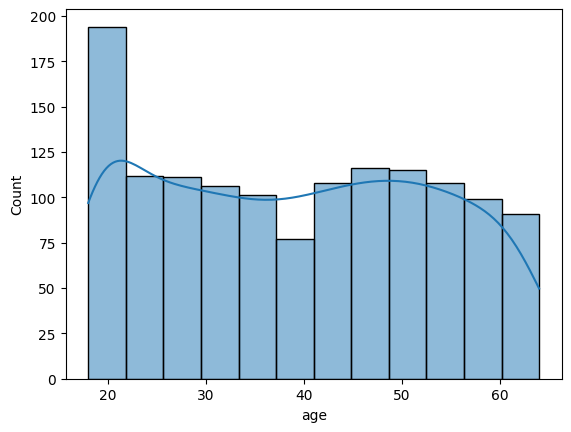

In [22]:
#histogram of dataset
sns.histplot(data=insurance['age'], kde=True)



<Axes: xlabel='charges', ylabel='Count'>

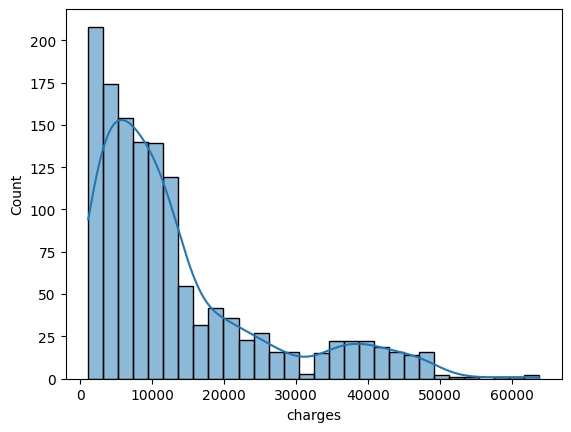

In [23]:
#charge histogram
sns.histplot(data=insurance['charges'], kde=True)


In [25]:
#calculate iqr for charges
Q1 = insurance["charges"].quantile(0.25)
Q3 = insurance["charges"].quantile(0.75)
IQR = Q3 - Q1
print(Q1 )
print(Q3)   
print(IQR)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(upper_bound.round(3)  )
print(lower_bound.round(3))


4740.28715
16639.912515
11899.625365
34489.351
-13109.151


In [26]:
#outliers in charges
outliers = insurance[(insurance["charges"] < lower_bound) | (insurance["charges"] > upper_bound)]
outliers


,age,sex,bmi,children,smoker,region,charges,age_group
14,27,0,42.130,0,yes,southeast,39611.75770,19-30
19,30,0,35.300,0,yes,southwest,36837.46700,19-30
23,34,1,31.920,1,yes,northeast,37701.87680,31-45
29,31,0,36.300,2,yes,southwest,38711.00000,31-45
30,22,0,35.600,0,yes,southwest,35585.57600,19-30
...,...,...,...,...,...,...,...,...
1300,45,0,30.360,0,yes,southeast,62592.87309,31-45
1301,62,0,30.875,3,yes,northwest,46718.16325,60+
1303,43,0,27.800,0,yes,southwest,37829.72420,31-45
1313,19,1,34.700,2,yes,southwest,36397.57600,19-30


<Axes: xlabel='charges'>

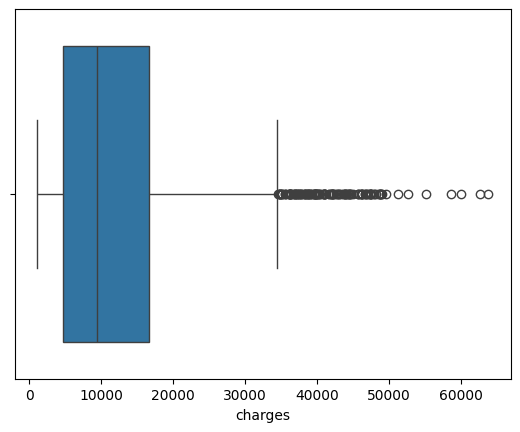

In [27]:
#boxplot of charges
sns.boxplot(x=insurance["charges"])


<Axes: xlabel='charges'>

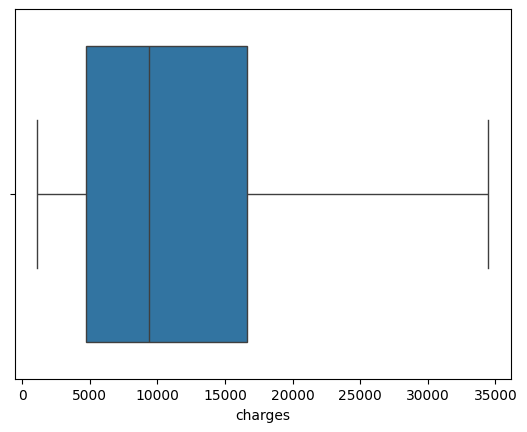

In [28]:
#boxplot of charges excluding outliers
sns.boxplot(x=insurance["charges"], showfliers=False)   


AttributeError: module 'seaborn' has no attribute 'legend'

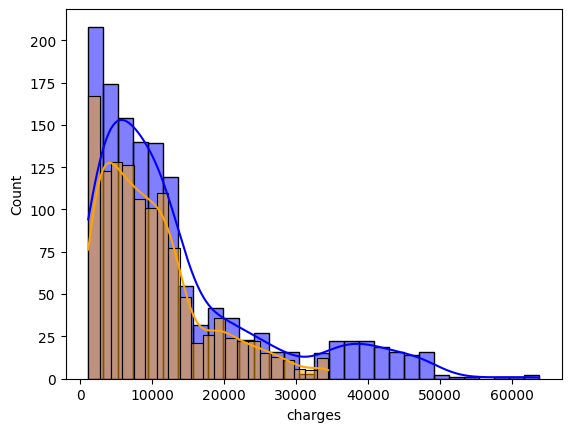

In [ ]:
#histogram  comparing charges with and without outliers in different figures
sns.histplot(insurance["charges"], kde=True, label="With Outliers", color="blue", alpha=0.5)
sns.histplot(insurance["charges"][~insurance["charges"].isin(outliers["charges"])], kde=True, label="Without Outliers", color="orange", alpha=0.5) 


